![](https://raw.githubusercontent.com/wateraccounting/WaPORMOOC/main/images/banner_notebooks_WaPOR4Global.png)


<div style="text-align:center; margin-top:15px;">
<h3 style="color:#D9E6F2; margin-bottom:5px;">
<i>Module Three</i> – Topic 2 - <b>Focus on Agriculture in Erbil</b>
</h3>

---


### 📚 Course Information

| Item | Description |
|------|-------------|
| **Course** | MOOC — WaPOR for Global Challenges |
| **Lesson** | 2 of 3: Correlation Analyses |
| **Focus** | Water use, biomass production of cropland in Erbil |
| **Region** | Erbil Governorate, Kurdistan Region of Iraq |
| **Data** | monthly WaPOR observations (2018-2025) |

---

### 🎯 Learning Objectives

By the end of this notebook, you will be able to:

1. **Compare** AgERA5 and WaPOR precipitation and reference ET data
4. **Compare** actual water use (AETI) and Biomass (NPP) against atmospheric demand (RET) and supply (PCP)
3. **Assess** water productivity — how much biomass per unit of water consumed
5. **Identify** the years and seasons where Erbil's agriculture was most stressed

---

### 📖 Table of Contents

1. Recap — From Country to Governorate
2. Understanding the WaPOR Variables
3. Setup & Data Loading
4. Comparing WaPOR and AgERA5 climate data (PCP and RET)
5. Climatic impact on cropland in Erbil
6. Analyses of annual values
7. Comparing variables
8. Seasonal Deep Dive
9. What's Next?

---

## 1. Recap — From Country to Governorate

> In **Topic 1**, we painted the **wide-angle picture**: four decades of rainfall and reference ET across all 18 Iraqi governorates. We discovered that:
>
> - Iraq has a **structural water deficit** — annual ET demand exceeds rainfall everywhere
> - The **north–south gradient**  Kurdistan gets 5–10× more rain than Basrah
> - **Trends are concerning** — several governorates show declining rainfall
> - **Drought is synchronous** — bad years tend to hit most of Iraq simultaneously

Now we **zoom in**. We leave the country-level climate records behind and pick up **satellite-derived agricultural data from FAO WaPOR** for a single governorate: **Erbil**.

### 📍 Why Erbil?

| Reason | Detail |
|--------|--------|
| **Strategic importance** | Capital of Kurdistan Region; major agricultural area |
| **Climate position** | Semi-arid — enough rain for rainfed farming, but vulnerable to drought |
| **Data availability** | WaPOR v3 provides high-quality monthly estimates |
| **Transition zone** | Between the wetter mountains (Sulaymaniyah) and drier central Iraq |

### 🔎 What changes at this zoom level?

| Topic 1 (Country) | Topic 2 (Erbil) |
|-------------------|-----------------|
| AgERA5 data | **Level-2** WaPOR products |
| PCP + RET only | **PCP + RET + AETI + NPP** |
| Broad climate characterisation | **Evaluating impact** on croplands |
| Annual / seasonal overview | **Crop season analyses**  |
| "Is it dry?" | **"How is agriculture responding?"** |


For the analyses, we first start with the comparison of the two precipitation and reference ET products (AgERA5 and WaPOR). In the second part we compare the four WaPOR data products (precipitation, reference ET, actual ET and Net Primary Production). In a separate Notebook **(link)** we will be exploring the irrigation dynamics in Erbil using WaPOR data stored in Google Earth Engine.

---
## ⚙️ 3.  Setup & Data Loading
<p style="margin-top:1px;">
	Some Python packages are required that may not be included in a basic Python installation. Run the cells below to set up your environment.
	</p>

In [2]:
# =============================================================================
# INSTALL & IMPORT PACKAGES
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import os
import warnings
from datetime import datetime

print(f"\n✅ Setup complete — Pandas {pd.__version__}, NumPy {np.__version__}")
print(f"📅 Analysis date: {datetime.now().strftime('%Y-%m-%d')}")


✅ Setup complete — Pandas 2.2.2, NumPy 2.0.2
📅 Analysis date: 2026-05-29


Create folders for where to upload the input data and where to store the results.

In [3]:
# =============================================================================
# CREATE INPUT AND OUTPUT FOLDERS
# =============================================================================

data_folder = 'data'
os.makedirs(data_folder, exist_ok=True)

output_folder = 'output_data'
os.makedirs(output_folder, exist_ok=True)



---
### Input data preparation

Place your WaPOR monthly CSV files in the `data/` folder:

| File | Variable | Description |Section|
|------|----------|-------------|-------|
| `irq_admin1_AgERA5-PCP-M_mm` | PCP* | Monthly precipitation (mm) |1|
| `irq_admin1_AgERA5-RET-M_mm` | RET* | Monthly reference ET (mm) |1|
| `irq_admin1_L1-PCP-M_mm_per_month` | PCP* | Monthly precipitation (mm) |1&2|
| `irq_admin1_L1-RET-M_mm_per_month` | RET* | Monthly reference ET (mm) |1&2|
| `ESA_LC_2021_Erbil_20m_L2-AETI-M_mm_per_month` | AETI** | Monthly actual ET & interception (mm) | 2 |
| `ESA_LC_2021_Erbil_20m_L2-NPP-M_gc_per_m2_per_month` | NPP** | Monthly net primary production (gC/m²) | 2|

**Expected format:**

'* First column = date (`DD/MM/YYYY`), remaining columns = Governorates.

'** First column = date (`DD/MM/YYYY`), remaining columns = land cover classes (.., Grassland, **Cropland**, ..).

📂 Upload your data files

- **Run the cell below** to browse and select your files (you can run it multiple times).  
- **OR drag your files** directly into the `data/` folder in the Files panel (left sidebar).

In [ ]:
# Upload data.
from google.colab import files
uploaded = files.upload()

# Save each file to the destination folder
for filename, content in uploaded.items():
    dest_path = f'/content/data/{filename}'
    with open(dest_path, 'wb') as f:
        f.write(content)
    print(f" Saved: {dest_path}")

---
### Create function to read data
We first make a function that reads the information in the files and extracts the information from the right column. For the PCP and RET data, we use the file from Exercise 1 and extract only column **`Erbil`**. For data used in the second part of the Notebook, we extract the data in the column **`40`**, which aligns with the cropland class.  

In [5]:
# =============================================================================
# DATA LOADING — WAPOR MONTHLY (CROPLAND CLASS 40/ OR GOVERNORATE ERBIL)
# =============================================================================

#COL_NAME = '40'   # Land cover class 40 = Cropland OR
#COL_NAME = 'Erbil'

def load_wapor_variable(filepath, var_name, COL_NAME):
    """
    Load a WaPOR monthly CSV and extract the cropland (class 40) column.
    Load a AgERA monthly CSV and extract the governorate (Erbil) column.

    Expected format:
    - First column = date (DD/MM/YYYY or similar)
    - Remaining columns = land cover classes (..., 30, 40, ...) OR governorates (..,Erbil, ...)
    """
    df = pd.read_csv(filepath)
    date_col = df.columns[0]

    # Parse dates
    for fmt in ['%d/%m/%Y', '%m/%d/%Y', '%Y-%m-%d', '%Y/%m/%d']:
        try:
            df[date_col] = pd.to_datetime(df[date_col], format=fmt)
            break
        except (ValueError, TypeError):
            continue
    else:
        df[date_col] = pd.to_datetime(df[date_col], dayfirst=True)

    df.set_index(date_col, inplace=True)
    df.index.name = 'date'
    df = df.sort_index()

    # Find the cropland column (might be int or string)
    col_match = None
    for col in df.columns:
        if str(col).strip() == COL_NAME:
            col_match = col
            break

    if col_match is None:
        raise KeyError(f"Column '{COL_NAME}' not found. Available: {df.columns.tolist()}")

    series = pd.to_numeric(df[col_match], errors='coerce')
    series.name = var_name

    print(f"📄 {var_name}: {len(series)} months | "
          f"{series.index.min().strftime('%b %Y')} — {series.index.max().strftime('%b %Y')} | "
          f"Mean: {series.mean():.2f}")
    return series



---

## 4. Comparing WaPOR and AgERA5 climate data (PCP and RET)
In this section we focus on comparing the climate data from AgERA5 and WaPOR. First we load the PCP and RET data from WaPOR and AgERA5 using the function above.

In [ ]:
# =============================================================================
# READ CLIMATE DATA USING FUNCTION AND COMBINE IN SINGLE DATAFRAME
# =============================================================================

print("="*70)
print("LOADING WAPOR AND AgERA5 CLIMATE DATA FOR ERBIL")
print("="*70)

files = {
    'PCP_WaPOR':  os.path.join('/content/data/irq_admin1_L1-PCP-M_mm_per_month.csv'),
    'RET_WaPOR':  os.path.join('/content/data/irq_admin1_L1-RET-M_mm_per_month.csv'),
    'PCP_AgERA5': os.path.join('/content/data/irq_admin1_AgERA5-PCP-M_mm.csv'),
    'RET_AgERA5':  os.path.join('/content/data/irq_admin1_AgERA5-RET-M_mm.csv')
}

series_dict = {}
for var_name, fpath in files.items():
    col_name = 'Erbil'
    if os.path.exists(fpath):
        series_dict[var_name] = load_wapor_variable(fpath, var_name, col_name)
    else:
        raise FileNotFoundError(f"File not found: {fpath}")

# Combine into a single DataFrame
df = pd.DataFrame(series_dict)
df = df.sort_index()

print(f"\n✅ Combined DataFrame: {df.shape[0]} months × {df.shape[1]} variables")
print(f"   Period: {df.index.min().strftime('%b %Y')} — {df.index.max().strftime('%b %Y')}")
print(f"   Missing values: {df.isnull().sum().sum()}")

The overview indicates a large amount of missing data. What is the source of the missing data?

<details>
  <summary>HINT</summary>

*  Missing data is only from WaPOR, which only has data from 2018-present (period of 1980-2017 is missing)

</details>

Lets calculate the statistics of the dataframe.

In [ ]:
# =============================================================================
# INSPECT THE DATA AND CALCULATE STATISTICS
# =============================================================================
print(df)

print("\n📊 Descriptive Statistics:")
display(df.describe().round(2))


Lets plot the precipitation data first by running the script as it is. You can see the period where the two datasets overlap. Comment the section "Present all data" out and uncomment the section "Filter for overlapping period where both series have data", and see the results.

In [ ]:
# =============================================================================
# PLOT TWO VARIABLES
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(15, 5), sharex=True)

ax = axes

#Present all data
#ax.plot(df.index, df['PCP_AgERA5'], color='#d6604d', linewidth=1, alpha=0.5, label='PCP_AgERA5')
#ax.fill_between(df.index, 0, df['PCP_WaPOR'], color='#1b7837', alpha=0.4, label='PCP_WaPOR')

#Filter for overlapping period where both series have data
overlapping_df = df[['PCP_AgERA5', 'PCP_WaPOR']].dropna()
ax.plot(overlapping_df.index, overlapping_df['PCP_AgERA5'], color='#d6604d', linewidth=1, alpha=0.5, label='PCP_AgERA5')
ax.fill_between(overlapping_df.index, 0, overlapping_df['PCP_WaPOR'], color='#1b7837', alpha=0.4, label='PCP_WaPOR')

# Adding graphic elements
ax.set_ylabel('mm/month')
ax.set_title('WaPOR PCP vs. AgERA5 PCP', fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.2)

Lets plot the two variables using a scatterplot.

In [ ]:
# =============================================================================
# SCATTERPLOT OF TWO VARIABLES
# =============================================================================


fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# Scatter: PCP comparison WaPOR vs AgERA5
ax = axes
ax.scatter(df['PCP_WaPOR'], df['PCP_AgERA5'])

# Adding graphic elements
ax.set_xlabel('PCP_WaPOR (mm/month)')
ax.set_ylabel('PCP_AgERA5 (mm/month)')
ax.set_title('Comparing PCP products', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lets add the regression line, its slope and intercept and the Coefficient of determination (r<sup>2</sup>).

In [ ]:
# =============================================================================
# SCATTERPLOT OF TWO VARIABLES
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# Scatter: PCP comparison WaPOR vs AgERA5
ax = axes
ax.scatter(df['PCP_WaPOR'], df['PCP_AgERA5'],
                 s=40, alpha=0.7, edgecolors='white', linewidth=0.3)

# Fit and plot line and add label
mask_valid = df[['PCP_WaPOR', 'PCP_AgERA5']].dropna()
if len(mask_valid) > 2:
    slope, intercept, r, p, se = stats.linregress(mask_valid['PCP_WaPOR'], mask_valid['PCP_AgERA5'])
    x_fit = np.linspace(mask_valid['PCP_WaPOR'].min(), mask_valid['PCP_WaPOR'].max(), 100)
    ax.plot(x_fit, intercept + slope * x_fit, 'r--', linewidth=2,
             label=f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r**2:.2f}')

# Adding graphic elements
ax.set_xlabel('PCP_WaPOR (mm/month)')
ax.set_ylabel('PCP_AgERA5 (mm/month)')
ax.set_title('Comparing PCP products', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Lets calculate the correlation between the different variables using the `.corr` function.

In [ ]:
# =============================================================================
# CALCULATE THE CORRELATION BETWEEN THE VARIABLES IN THE DATAFRAME
# =============================================================================

clim_corr=df.corr()#**2
print(clim_corr.round(2))

When comparing the results with what is presented in the scatterplot the values are different. Do you know why?

<details>
  <summary>ANSWER</summary>

*  the function `.corr` calculates the correlation (r), whereas in the scatterplot the r^2 is provided. Uncomment **2 to calculate the square of r.

</details>

---
Lets calculate additional correlation statistics between the AgERA5 and WaPOR Precipitation products.

| Stat | Description |Unit|
|------|----------|-------------|
| r^2 | Coefficient of determination | -|
|RMSE| Root mean square error|mm/month|
| Bias | Bias | mm/month |
| PBias | percentage bias | % |



In [ ]:
# =============================================================================
# CALCULATE STATISTICS BETWEEN PCP VARIABLES IN THE DATAFRAME
# =============================================================================

import numpy as np
from sklearn.metrics import mean_squared_error

# Filter for overlapping period where both series have data
comparison_df = df[['PCP_WaPOR', 'PCP_AgERA5']].dropna()

# Ensure there is enough data for comparison
if len(comparison_df) < 2:
    print("Not enough overlapping data for PCP_WaPOR and PCP_AgERA5 to perform comparison.")
else:
    observed = comparison_df['PCP_AgERA5'].values
    predicted = comparison_df['PCP_WaPOR'].values

    # 1. Calculate R-squared (R2) using a direct correlation for consistency with previous R-squared calculation method
    r2 = comparison_df.corr().iloc[0, 1]**2

    # 2. Calculate RMSE using scikit-learn
    rmse = np.sqrt(mean_squared_error(observed, predicted))

    # 3. Calculate Bias
    bias = np.mean(predicted - observed)

    # 4. Calculate Percentage Bias (PBIAS)
    sum_diff = np.sum(predicted - observed)
    sum_observed = np.sum(observed)

    if sum_observed != 0:
        pbias = (sum_diff / sum_observed) * 100
    else:
        pbias = np.nan # Avoid division by zero

    print(f"Comparison of PCP_WaPOR (predicted) and PCP_AgERA5 (observed) (N={len(comparison_df)}):")
    print(f"  R-squared (R2): {r2:.2f}")
    print(f"  RMSE: {rmse:.2f} mm/month")
    print(f"  Bias: {bias:.2f} mm/month")
    print(f"  Percentage Bias (PBIAS): {pbias:.2f} %")


Repeat the analyses for RET and answer the following questions:

- What is the regression line between the two RET products?
- What are the correlation statistics (R^2, RMSE, Bias and Percentage bias) when comparing the two RET products?


In [ ]:
# =============================================================================
# SCATTERPLOT OF TWO VARIABLES
# =============================================================================


fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# Scatter: RET comparison WaPOR vs AgERA5

### ✍ Conclusion
Advantage of AgERA5 is the long time series, both data sets can be accessed using the WaPOR download API and have the same data format structure. For the next part we will be using the WaPOR data to compare to the AETI and NPP for croplands in Erbil.  



---

## 5. Climatic impact on cropland in Erbil

In this section we further dive into croplands in Erbil to evaluate the impact of the climate drivers (PCP and RET) on agricultural water use (AETI) and crop production (NPP).

In addition to the WaPOR PCP and RET, we use the WaPOR AETI and NPP monthly time series, extracted for **cropland** areas (Land Cover Class 40) within Erbil Governorate.

**Overview of the Variables used in this section:**

| Variable | Full Name | Unit | What It Tells Us |
|----------|-----------|------|-----------------|
| **WaPOR_PCP** | Precipitation | mm/month | 🌧️ Water **supply** — how much rain falls |
| **WaPOR_RET** | Reference Evapotranspiration | mm/month | ☀️ Atmospheric **demand** — how much water the atmosphere wants |
| **WaPOR_AETI** | Actual Evapotranspiration & Interception | mm/month | 💧 Actual water **consumption** by crops and soil |
| **WaPOR_NPP** | Net Primary Production | gC/m²/month | 🌱 Biomass **production** — photosynthetic output |


In this section we will explore the following relationships:

- **PCP vs AETI** → Is actual water use exceeding rainfall? (irrigation dependency)
- **RET vs AETI** → How much of the demand is actually met? (indicator of stress)
- **NPP / AETI** → **Water productivity** — biomass produced per mm of water consumed

Before running the codes, ensure that you have uploaded the following files in the `data/` folder:

| File | Variable | Description |
|------|----------|-------------|
| `irq_admin1_L1-PCP-M_mm_per_month` | PCP* | Monthly precipitation (mm) |
| `irq_admin1_L1-RET-M_mm_per_month` | RET* | Monthly reference ET (mm) |
| `ESA_LC_2021_Erbil_20m_L2-AETI-M_mm_per_month` | AETI** | Monthly actual ET & interception (mm) |
| `ESA_LC_2021_Erbil_20m_L2-NPP-M_gc_per_m2_per_month` | NPP** | Monthly net primary production (gC/m²) |

The following cell reads the uploaded .csv files and extracts the correct column (Erbil for the climatic data and cropland `40` for the agricultural data). It creates a new data frame `df2` with the data.

In [ ]:
# =============================================================================
# READ CLIMATE DATA USING FUNCTION AND COMBINE IN SINGLE DATAFRAME
# =============================================================================

files = {
    'PCP_WaPOR':  os.path.join('/content/data/irq_admin1_L1-PCP-M_mm_per_month.csv'),
    'RET_WaPOR':  os.path.join('/content/data/irq_admin1_L1-RET-M_mm_per_month.csv'),
    'AETI_WaPOR': os.path.join('/content/data/ESA_LC_2021_Erbil_20m_L2-AETI-M_mm_per_month.csv'),
    'NPP_WaPOR':  os.path.join('/content/data/ESA_LC_2021_Erbil_20m_L2-NPP-M_gc_per_m2_per_month.csv')
}

series_dict = {}
for var_name, fpath in files.items():
    col_name = 'Cropland' if 'AETI' in var_name or 'NPP' in var_name else 'Erbil'
    if os.path.exists(fpath):
        series_dict[var_name] = load_wapor_variable(fpath, var_name, col_name)
    else:
        raise FileNotFoundError(f"File not found: {fpath}")

# Combine into a single DataFrame
df2 = pd.DataFrame(series_dict)
df2 = df2.sort_index()

print(f"\n✅ Combined DataFrame: {df2.shape[0]} months × {df2.shape[1]} variables")
print(f"   Period: {df2.index.min().strftime('%b %Y')} — {df2.index.max().strftime('%b %Y')}")
print(f"   Missing values: {df2.isnull().sum().sum()}")

In [ ]:
# =============================================================================
# INSPECT THE DATA AND CALCULATE STATISTICS
# =============================================================================

print(df2)

print("\n📊 Descriptive Statistics:")
display(df2.describe().round(2))


Let's plot the dataframe using the `.plot` function and add the legend. To plot only a selection of the variables, run the second line in the cell below.

Notice that if you put 'legend' as 'True' you get a legend in the figure.

In [ ]:
# =============================================================================
# VISUALISE THE TIMESERIES
# =============================================================================

df2.plot(legend=True, xlabel='date')
#df2[['PCP_WaPOR', 'AETI_WaPOR']].plot(legend=True)

---
##6. Analyses of annual values
Lets have a look at the data first and generate the annual values and add then to a data frame.

In [18]:
annual_pcp = df2['PCP_WaPOR'].resample('YE').sum()
annual_ret = df2['RET_WaPOR'].resample('YE').sum()
annual_aeti = df2['AETI_WaPOR'].resample('YE').sum()
annual_npp = df2['NPP_WaPOR'].resample('YE').sum()

annual_summary = pd.DataFrame({
    'Annual PCP (mm/year)': annual_pcp,
    'Annual RET (mm/year)': annual_ret,
    'Annual AETI (mm/year)': annual_aeti,
    'Annual NPP (mm/year)': annual_npp
})

display(annual_summary)


,Annual PCP (mm/year),Annual RET (mm/year),Annual AETI (mm/year),Annual NPP (mm/year)
date,,,,
2018-12-31,1301.93,1451.64,285.68,202.43
2019-12-31,1055.93,1449.77,411.38,343.92
2020-12-31,769.67,1542.72,361.06,294.42
2021-12-31,553.37,1667.51,263.04,165.58
2022-12-31,547.10,1574.67,287.26,185.68
2023-12-31,644.80,1534.49,347.72,290.67
2024-12-31,721.81,1542.72,391.33,357.18
2025-12-31,579.99,1638.64,299.89,199.21


Lets calculate if there was sufficient rainfall to account for the water consumption of the crops by calculating the difference and adding the results to the data frame.

In [ ]:
annual_summary['Annual (PCP-AETI) (mm/year)'] = annual_summary['Annual PCP (mm/year)'] - annual_summary['Annual AETI (mm/year)']
display(annual_summary.round(2))

Note that all years the annual precipitation exceeds the agricultural water consumption.

Repeat the steps and calculate the difference between the climatic water demand (RET) and the actual water use (AETI) for each year.

 🔔 **QUIZ**: Which year had the highest deficit (RET-AETI)? and how much is this deficit in mm/year (no digits). Note down your answer you need it for the quiz!!

---
Now lets plot the annual values of each variable using one code using `plt.subplots`

In [ ]:
# =============================================================================
# ANNUAL COMPARISON
# =============================================================================

# Extract the years from the DataFrame index for plotting
years = annual_summary.index.year

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Annual Totals of WaPOR Variables', fontsize=16, fontweight='bold') # Changed suptitle

variables = ['Annual PCP (mm/year)', 'Annual RET (mm/year)', 'Annual AETI (mm/year)', 'Annual NPP (mm/year)']
y_labels = {
    'Annual PCP (mm/year)': 'Total Precipitation (mm/year)',
    'Annual RET (mm/year)': 'Total Reference ET (mm/year)',
    'Annual AETI (mm/year)': 'Total Actual ET (mm/year)',
    'Annual NPP (mm/year)': 'Total Net Primary Production (gC/m²/year)'
}

for idx, var in enumerate(variables):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    # Plot using the extracted years and the corresponding column from annual_summary_df
    ax.plot(years, annual_summary[var], marker='o', linestyle='-', label='Annual Total', color='#2166ac') # Changed label

    ax.set_title(var.replace(" (mm/year)", "").replace(" (gC/m²)", "").replace("Annual ", ""), fontsize=12, fontweight='bold') # Adjusted title formatting
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel(y_labels[var], fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.2)
    ax.set_xticks(years) # Set x-ticks to display all years
    ax.tick_params(axis='x', rotation=45) # Rotate x-axis labels for readability

plt.tight_layout()
plt.show()

🔔 **Discuss:** Based the timeseries available in WaPOR (2018-2025), which year is the wettest and which year is the driest? Taking into consideration RET (by calculating PCP-RET) is the same year still the driest? Did the climatic variables in all years have the same impact on agricultural water consumption and biomass production?

---

Lets create a summary table with all the variables, some additional calculations and save it as a csv file.

In [ ]:
# =============================================================================
# ANNUAL SUMMARY TABLE
# =============================================================================

annual_summary = pd.DataFrame()
annual_summary['PCP (mm)']  = df2.resample('YE')['PCP_WaPOR'].sum()
annual_summary['RET (mm)']  = df2.resample('YE')['RET_WaPOR'].sum()
annual_summary['AETI (mm)'] = df2.resample('YE')['AETI_WaPOR'].sum()
annual_summary['NPP (gC/m²)'] = df2.resample('YE')['NPP_WaPOR'].sum()
annual_summary['PCP-AETI (mm)'] = annual_summary['PCP (mm)'] - annual_summary['AETI (mm)']
annual_summary['PCP-RET (mm)'] = annual_summary['PCP (mm)'] - annual_summary['RET (mm)']
annual_summary['AETI/RET']  = annual_summary['AETI (mm)'] / annual_summary['RET (mm)']
annual_summary['WP (gC/mm)'] = annual_summary['NPP (gC/m²)'] / annual_summary['AETI (mm)']

annual_summary.index = annual_summary.index.year
annual_summary.index.name = 'Year'

print("="*90)
print("ANNUAL SUMMARY — ERBIL CROPLAND")
print("="*90)
display(annual_summary.round(1))

# Save
annual_summary.to_csv(os.path.join(output_folder, 'erbil_cropland_annual_summary.csv'))
print("\n✅ Saved to output_data/erbil_cropland_annual_summary.csv")

Lets interrogate the new dataframe and report the results  

In [ ]:
# =============================================================================
# Identify extremes
# =============================================================================

driest_yr   = annual_summary['PCP (mm)'].idxmin()
wettest_yr  = annual_summary['PCP (mm)'].idxmax()
best_wp_yr  = annual_summary['WP (gC/mm)'].idxmax()
worst_wp_yr = annual_summary['WP (gC/mm)'].idxmin()

print(f"💡 Year Rankings:")
print(f"   Driest:  {driest_yr} ({annual_summary.loc[driest_yr, 'PCP (mm)']:.0f} mm rainfall)")
print(f"   Wettest: {wettest_yr} ({annual_summary.loc[wettest_yr, 'PCP (mm)']:.0f} mm rainfall)")
print(f"   Most productive:  {best_wp_yr} (WP = {annual_summary.loc[best_wp_yr, 'WP (gC/mm)']:.2f})")
print(f"   Least productive: {worst_wp_yr} (WP = {annual_summary.loc[worst_wp_yr, 'WP (gC/mm)']:.2f})")

---
##7. Comparing variables

Calculate the correlation beween variables in the dataframe.

In [ ]:
# =============================================================================
# CALCULATE CORRELATION BETWEEN VARIABLES IN DATAFRAME
# =============================================================================

corr = df2.corr()**2
print(corr.round(2))


🔔 **QUIZ**: Which variables have the highest correlation? and what is the correlation?

- Note down the answer you need it for the quiz!

- Why are we not calculating the RMSE and Bias?

---
From the correlation calculation, the precipitation and AETI do not have a good correlation, indicating that the water consumption in the croplands are not dependent on rainfall. Lets plot the two variables against each other (create a scatterplot for PCP vs AETI), including statistics and linear regression in the graph. We also added a coloring of the points to indicate which months each data point is generated from.  

In [ ]:
# =============================================================================
# SCATTERPLOT OF TWO VARIABLES
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# Scatter: AETI vs PCP
ax = axes
sc = ax.scatter(df2['PCP_WaPOR'], df2['AETI_WaPOR'],c=df2.index.month,
                 cmap='twilight', s=35, alpha=0.7)

# Fit line & display statistics
slope, intercept, r, p, se = stats.linregress(df2['PCP_WaPOR'], df2['AETI_WaPOR'])
x_fit = np.linspace(df2['AETI_WaPOR'].min(), df2['PCP_WaPOR'].max(), 100)
ax.plot(x_fit, intercept + slope * x_fit, 'r--', linewidth=2,label=f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r**2:.2f}')

ax.set_xlabel('PCP (mm/month)')
ax.set_ylabel('AETI (mm/month)')
ax.set_title('Rainfall - Water Use Relationship', fontweight='bold')
ax.legend()

# Add a colorbar for the month
plt.colorbar(sc, ax=ax, label='Month')

plt.tight_layout()
plt.show()

It is clear that there are two different periods in the year where AETI is responding differently to increase in PCP. In the winter months (November to February) there is high precipitation and low water consumption, compared to the summer months where AETI is high compared to low or zero precipitation. This illustrates that there are other sources of water during the summer months, whereas during the winter months, the limiting factor is the atmospheric water demand. Lets illustrate this by having a closer look at the timeseries and highlight when AETI exceeds PCP.

In [ ]:
# =============================================================================
# Irrigation needs — AETI / PCP
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(15, 5), sharex=True)

# --- AETI vs PCP ---
ax = axes
ax.plot(df2.index, df2['PCP_WaPOR'], color='black', linewidth=1, alpha=0.5, label='PCP')
ax.fill_between(df2.index, df2['PCP_WaPOR'], df2['AETI_WaPOR'], color='#1b7837', alpha=0.4, label='Water yield')

# Shade the gap (irrigation needs)
ax.fill_between(df2.index, df2['AETI_WaPOR'], df2['PCP_WaPOR'],
                 where=df2['PCP_WaPOR'] < df2['AETI_WaPOR'],
                 color='red', alpha=0.3, label='Irrigation needs')
ax.set_ylabel('mm/month')
ax.set_title('Precipitation  vs. Actual ET', fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.2)


Lets calculate the annual irrigation needs, during those months where PCP is less than AETI.

The results are different from the earlier calculations and shows a deficit, what is the reason for this?

<details>
<summary>ANSWER</summary>
The calculation using the annual data incorporates the surplus during the rainy season, whereas this calculation only considers the months where there is a deficit.
</details>

🔔 **Quiz question**:

Which year had the largest irrigation need?

In [26]:
monthly_PCP_AETI_difference = df2.loc[df2['PCP_WaPOR'] < df2['AETI_WaPOR'], ['PCP_WaPOR', 'AETI_WaPOR']].apply(lambda x: x['PCP_WaPOR'] - x['AETI_WaPOR'], axis=1)
annual_PCP_AETI_difference = monthly_PCP_AETI_difference.resample('YE').sum()

#print("Difference (PCP - AETI) for months where PCP < AETI:")
#print(monthly_PCP_AETI_difference)
print("Annual Difference (PCP - AETI):")
print(annual_PCP_AETI_difference)


Annual Difference (PCP - AETI):
date
2018-12-31    -90.00
2019-12-31   -149.13
2020-12-31   -135.27
2021-12-31    -98.44
2022-12-31   -107.81
2023-12-31   -102.75
2024-12-31    -89.76
2025-12-31    -91.62
Freq: YE-DEC, dtype: float64


Repeat the analyses using RET and AETI and answer the following questions:

- The slope between RET and AETI is highest in the summer or winter season?
- The deficit between climatic demand (RET) and actual water use (AETI) is largest in which year?


In [ ]:
# =============================================================================
# SCATTERPLOT: RET vs AETI
# =============================================================================

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

In [ ]:
# =============================================================================
# DEFICIT: RET vs AETI
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(15, 5))


---

## 8. Seasonal Deep Dive

To get a better grip on the different cropping seasons (summer and winter), we first investigate the seasonality through the mean monthly values.

In [ ]:
# =============================================================================
# MONTHLY CLIMATOLOGY
# =============================================================================

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Compute monthly climatology
df2_month = df2.groupby(df2.index.month).mean()
df2_month.index = month_names

print(df2_month.round(2))

df2_month.plot(legend=True)

Erbil has two cropping seasons, winter and summer. One of the seasons is rainfed and one is fully dependent on irrigation.

| Season | Months | Character |
|--------|--------|-----------|
| **Wet/Growing** | Nov – May | Rainfall arrives; crops grow; AETI peaks during spring |
| **Dry/Fallow** | Jun – Oct | Virtually no rain; high ET demand; irrigation critical |

We decompose the data by season to see which months drive annual variability.
Lets summarise the data for the winter season first (which start each year in November and ends the following year in May).

In [ ]:
# =============================================================================
# AGGREGATE DATA FOR WINTER SEASON (NOVEMBER-MAY)
# =============================================================================

winter_season_data = [] # Initialize here to clear previous runs
# We want periods from Nov Y to May Y+1

start_year = df2.index.min().year
end_year = df2.index.max().year

# Loop through relevant years for the start of the season
for year in range(start_year, end_year):
    season_start = pd.Timestamp(f'{year}-11-01')
    season_end = pd.Timestamp(f'{year + 1}-05-31')

    # Check if the season is fully contained within the DataFrame's date range
    if season_start >= df2.index.min() and season_end <= df2.index.max():
        season_period_df = df2.loc[season_start:season_end]

        # Sum the values for the season
        season_sum = season_period_df.sum().to_dict()
        season_sum['Season'] = f'Nov {year} - May {year+1}'
        winter_season_data.append(season_sum)

# Create a DataFrame from the seasonal sums
df_winter_sums = pd.DataFrame(winter_season_data)

# Set Season as index and reorder columns for better readability
df_winter_sums = df_winter_sums.set_index('Season')
df_winter_sums = df_winter_sums[['PCP_WaPOR', 'RET_WaPOR', 'AETI_WaPOR', 'NPP_WaPOR']]

print("Seasonal Sums (Nov-May):")
display(df_winter_sums)

Calculate the correlation between the different variables in the winter season. Do you notice that the correlation between PCP and the agricultural variables is much higher than when it is compared for annual values, indicating a more direct agricultural response to rainfall.

In [31]:
# =============================================================================
# CALCULATE CORRELATION OF DATA FOR WINTER SEASON (NOVEMBER-MAY)
# =============================================================================

corr_winter=df_winter_sums.corr()**2
print(corr_winter.round(2))

            PCP_WaPOR  RET_WaPOR  AETI_WaPOR  NPP_WaPOR
PCP_WaPOR        1.00       0.86        0.38       0.45
RET_WaPOR        0.86       1.00        0.43       0.53
AETI_WaPOR       0.38       0.43        1.00       0.98
NPP_WaPOR        0.45       0.53        0.98       1.00


Repeat analyses for the summer season (Jun-Oct) and answer the questions below.

In [35]:
# =============================================================================
# AGGREGATE DATA FOR SUMMER SEASON (JUN-OCT)
# =============================================================================

summer_season_data = [] # Initialize here to clear previous runs
# We want periods from Nov Y to May Y+1

start_year = df2.index.min().year
end_year = df2.index.max().year

# Loop through relevant years for the start of the season
for year in range(start_year, end_year):
    season_start = pd.Timestamp(f'{year}-06-01')
    season_end = pd.Timestamp(f'{year}-10-31')

    # Check if the season is fully contained within the DataFrame's date range
    if season_start >= df2.index.min() and season_end <= df2.index.max():
        season_period_df = df2.loc[season_start:season_end]

        # Sum the values for the season
        season_sum = season_period_df.sum().to_dict()
        season_sum['Season'] = f'Jun {year} - Oct {year}'
        summer_season_data.append(season_sum)

# Create a DataFrame from the seasonal sums
df_summer_sums = pd.DataFrame(summer_season_data)

# Set Season as index and reorder columns for better readability
df_summer_sums = df_summer_sums.set_index('Season')
df_summer_sums = df_summer_sums[['PCP_WaPOR', 'RET_WaPOR', 'AETI_WaPOR', 'NPP_WaPOR']]

print("Seasonal Sums (Nov-May):")
display(df_summer_sums)

Seasonal Sums (Nov-May):


,PCP_WaPOR,RET_WaPOR,AETI_WaPOR,NPP_WaPOR
Season,,,,
Jun 2018 - Oct 2018,52.17,973.10,110.89,14.41
Jun 2019 - Oct 2019,35.76,981.11,145.42,22.16
Jun 2020 - Oct 2020,7.40,1008.76,121.16,18.75
Jun 2021 - Oct 2021,19.52,1029.77,89.33,11.46
Jun 2022 - Oct 2022,9.17,1022.72,110.70,15.87
Jun 2023 - Oct 2023,22.73,987.25,109.70,19.15
Jun 2024 - Oct 2024,18.98,1001.80,108.74,18.48


In [33]:
# =============================================================================
# CALCULATE CORRELATION OF DATA FOR SUMMER SEASON (JUN-OCT)
# =============================================================================



In which season does AETI and NPP have the highest correlation with precipitation?

---

Now plot the two timeseries into one plot.

In [ ]:
# =============================================================================
# WET vs. DRY SEASON — ANNUAL COMPARISON
# =============================================================================


<details>
<summary>HINT</summary>
It should look like this

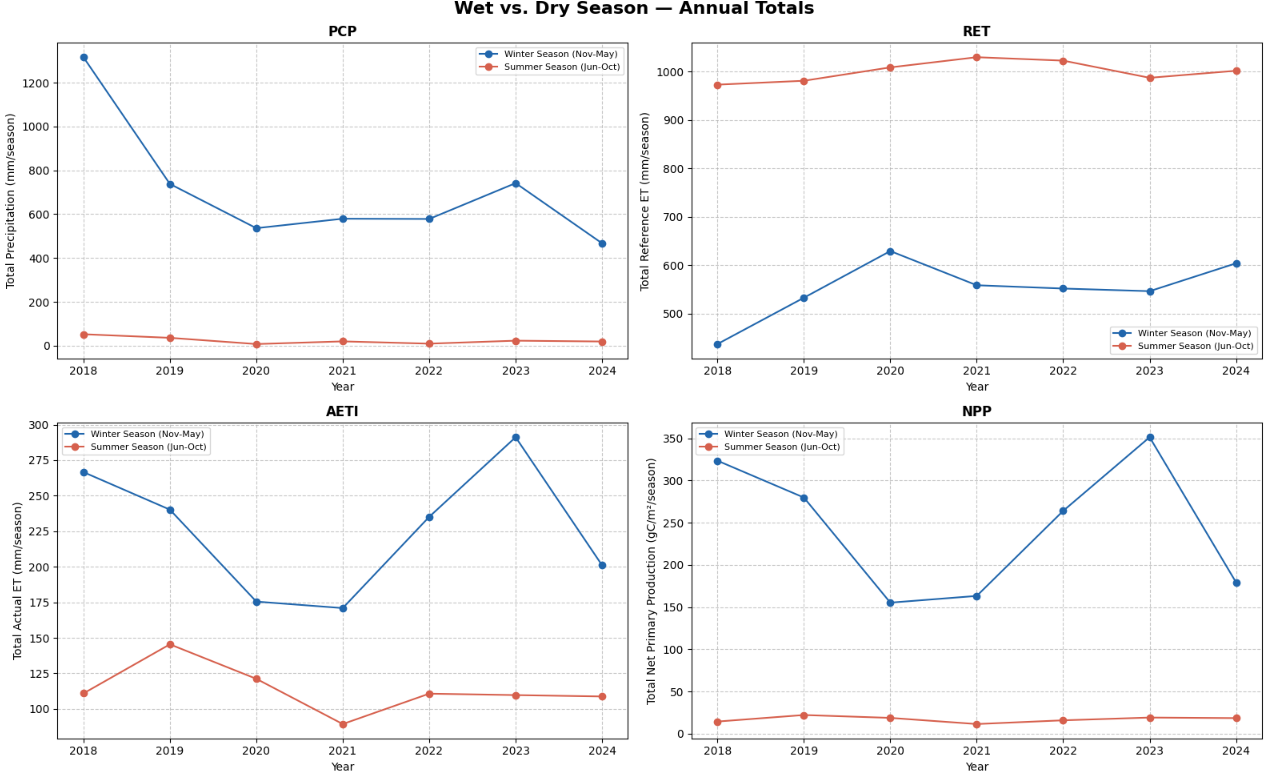
</details>

The results show a much higher AETI and NPP in the winter season for cropland, despite the cold conditions. During the summer crops are only able to grow where irrigation is applied. In the following Notebook <link> we will be using Google Earth Engine to estimate the irrigated area during the summer season.

### ➡️ What's Next?

> In **Topic 3**, we zoom to the **field level** — selecting approximately 13 centre-pivot irrigated fields near Erbil.
>
> There, we'll:
> - Apply **ARIMA and SARIMAX forecasting models** to predict water consumption
> - **Compare forecasting performance** across individual fields
> - Explore how field-level variability connects back to the governorate patterns we've analysed here
>
> This final step takes us from *"what's happening?"* and *"why?"* to *"what will happen next?"*

---

### 📚 References

1. **FAO WaPOR**: https://wapor.apps.fao.org/
2. **Water Productivity**: Bastiaanssen, W.G.M. & Steduto, P. (2017). The water productivity score (WPS) at global and regional level.

---

*End of Topic 2 — Proceed to Topic 3: Field-Level Forecasting*